In [1]:
# ============================================================
# Cell 1: Install & Imports
# ============================================================

!pip install requests feedparser beautifulsoup4 pandas tqdm \
             openpyxl wordcloud matplotlib seaborn -q

import requests, sqlite3, json, re, time, logging
import pandas as pd
import feedparser
from datetime       import datetime, timedelta
from bs4            import BeautifulSoup
from tqdm  import tqdm
from pathlib        import Path
import warnings
warnings.filterwarnings("ignore")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s"
)
logger = logging.getLogger(__name__)
print("✅ Imports done")


# ============================================================
# Cell 2: Verified Working Endpoints
# ============================================================

# ✅ CONFIRMED WORKING (from your debug output):
#
#   /pubs/{server}/{date_from}/{date_to}/{cursor}/json
#
#   Returns papers that were posted as preprints AND later
#   published in a peer-reviewed journal.
#   Fields: preprint_doi, published_doi, published_journal,
#           preprint_title, preprint_authors, preprint_category,
#           preprint_date, published_date, preprint_abstract,
#           preprint_author_corresponding,
#           preprint_author_corresponding_institution
#
# ❌ /details/{server}/... → "Not available at this time"
#
# ✅ SUPPLEMENTARY (RSS feeds, HTML search — covered below)

PUBS_BIORXIV  = "https://api.biorxiv.org/pubs/biorxiv"
PUBS_MEDRXIV  = "https://api.biorxiv.org/pubs/medrxiv"

# Quick confirmation
import requests
_r = requests.get(
    "https://api.biorxiv.org/pubs/biorxiv/2024-01-01/2024-01-07/0/json",
    timeout=20
)
_d = _r.json()
print("✅ /pubs/ endpoint confirmed working")
print(f"   Status  : {_d['messages'][0]['status']}")
print(f"   Total   : {_d['messages'][0]['total']}")
print(f"   Fields  : {list(_d['collection'][0].keys())}")


# ============================================================
# Cell 3: Configuration
# ============================================================

CONFIG = {
    "db_path": "biomaterials_papers.db",

    "keywords": [
        "biomaterials", "biocompatible", "scaffold", "hydrogel",
        "tissue engineering", "biodegradable polymer",
        "bone regeneration", "drug delivery", "nanoparticle",
        "bioceramic", "extracellular matrix", "collagen scaffold",
        "bioprinting", "3D bioprinting", "implant material",
        "wound healing scaffold", "biopolymer", "chitosan",
        "alginate", "PLGA", "poly lactic acid", "titanium implant",
        "hydroxyapatite", "cartilage regeneration", "vascular graft",
        "nerve conduit", "electrospinning", "fibrin scaffold",
        "decellularized matrix", "bioactive glass",
        "drug eluting", "controlled release", "nanomedicine",
        "liposome", "dendrimers", "microneedle", "bioreactor",
        "osseointegration", "periosteum", "angiogenesis scaffold",
    ],

    "request_delay": 1.2,       # seconds between API calls
    "max_retries"  : 4,

    # Date range — /pubs/ works well across any window
    "date_from": "2018-01-01",
    "date_to"  : datetime.today().strftime("%Y-%m-%d"),

    # Split into N-month chunks to avoid timeouts
    "chunk_months": 1,
}

print("✅ Config ready")
print(f"   Date range  : {CONFIG['date_from']} → {CONFIG['date_to']}")
print(f"   Keywords    : {len(CONFIG['keywords'])}")

✅ Imports done
✅ /pubs/ endpoint confirmed working
   Status  : ok
   Total   : 304
   Fields  : ['preprint_doi', 'published_doi', 'published_journal', 'preprint_platform', 'preprint_title', 'preprint_authors', 'preprint_category', 'preprint_date', 'published_date', 'preprint_abstract', 'preprint_author_corresponding', 'preprint_author_corresponding_institution']
✅ Config ready
   Date range  : 2018-01-01 → 2026-04-23
   Keywords    : 40


In [2]:
# ============================================================
# Cell 4: HTTP Session
# ============================================================

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept": "application/json",
})


def get_json(url: str, retries: int = 4) -> dict | None:
    """
    GET + JSON parse with retry/back-off.
    Returns parsed dict or None.
    """
    for attempt in range(retries):
        try:
            resp = SESSION.get(url, timeout=30)

            if resp.status_code == 200:
                data = resp.json()
                # Check the API-level status field
                msgs = data.get("messages", [{}])
                api_status = msgs[0].get("status", "") if msgs else ""

                if api_status == "ok":
                    return data
                elif api_status == "Not available at this time":
                    logger.warning(f"API not available: {url}")
                    time.sleep(10 * (attempt + 1))
                else:
                    # Unknown status — still return if collection present
                    if data.get("collection") is not None:
                        return data

            elif resp.status_code == 429:
                wait = 60 * (attempt + 1)
                logger.warning(f"Rate limited — waiting {wait}s")
                time.sleep(wait)

            elif resp.status_code in (500, 502, 503, 504):
                logger.warning(f"Server error {resp.status_code} — retry {attempt+1}")
                time.sleep(5 * (attempt + 1))

            else:
                logger.warning(f"HTTP {resp.status_code} for {url}")
                return None

        except requests.exceptions.Timeout:
            logger.warning(f"Timeout attempt {attempt+1}: {url}")
            time.sleep(5 * (attempt + 1))
        except requests.exceptions.ConnectionError as e:
            logger.warning(f"Connection error: {e}")
            time.sleep(10 * (attempt + 1))
        except Exception as e:
            logger.error(f"Unexpected error: {e}")
            time.sleep(5)

    return None


# Sanity check
_test = get_json(
    "https://api.biorxiv.org/pubs/biorxiv/2024-01-01/2024-01-03/0/json"
)
if _test:
    print(f"✅ get_json() works — {len(_test['collection'])} papers returned")
else:
    print("❌ get_json() failed — check connection")

✅ get_json() works — 100 papers returned


In [3]:
# ============================================================
# Cell 5: Database — Full Schema
# ============================================================

def init_db(path: str) -> sqlite3.Connection:
    conn = sqlite3.connect(path, check_same_thread=False)
    conn.executescript("""
        -- ── Main papers table ─────────────────────────────
        CREATE TABLE IF NOT EXISTS papers (
            id                          INTEGER PRIMARY KEY AUTOINCREMENT,

            -- Preprint identifiers
            preprint_doi                TEXT    UNIQUE,
            preprint_title              TEXT,
            preprint_abstract           TEXT,
            preprint_authors            TEXT,   -- raw string from API
            preprint_category           TEXT,
            preprint_date               TEXT,   -- YYYY-MM-DD
            preprint_platform           TEXT,   -- bioRxiv / medRxiv
            preprint_url                TEXT,
            preprint_pdf_url            TEXT,

            -- Published journal version (may be empty)
            published_doi               TEXT,
            published_journal           TEXT,
            published_date              TEXT,

            -- Corresponding author
            corresponding_author        TEXT,
            corresponding_institution   TEXT,

            -- Our metadata
            keywords_matched            TEXT,   -- JSON list
            source                      TEXT,   -- 'biorxiv' | 'medrxiv'

            -- Enrichment
            cited_by                    INTEGER DEFAULT 0,
            license                     TEXT,

            created_at                  TEXT    DEFAULT CURRENT_TIMESTAMP,
            updated_at                  TEXT    DEFAULT CURRENT_TIMESTAMP
        );

        -- ── Author details ─────────────────────────────────
        CREATE TABLE IF NOT EXISTS authors (
            id          INTEGER PRIMARY KEY AUTOINCREMENT,
            paper_doi   TEXT,
            name        TEXT,
            orcid       TEXT,
            institution TEXT,
            is_corresponding INTEGER DEFAULT 0,
            FOREIGN KEY (paper_doi) REFERENCES papers(preprint_doi)
        );

        -- ── Keyword hit log ────────────────────────────────
        CREATE TABLE IF NOT EXISTS keyword_hits (
            id        INTEGER PRIMARY KEY AUTOINCREMENT,
            paper_doi TEXT,
            keyword   TEXT,
            field_hit TEXT,   -- 'title'|'abstract'|'category'|'journal'
            FOREIGN KEY (paper_doi) REFERENCES papers(preprint_doi)
        );

        -- ── Scrape session log ─────────────────────────────
        CREATE TABLE IF NOT EXISTS sessions (
            id            INTEGER PRIMARY KEY AUTOINCREMENT,
            started_at    TEXT,
            finished_at   TEXT,
            source        TEXT,
            date_window   TEXT,
            total_fetched INTEGER DEFAULT 0,
            bio_found     INTEGER DEFAULT 0,
            new_inserted  INTEGER DEFAULT 0,
            status        TEXT
        );

        -- ── Indexes ────────────────────────────────────────
        CREATE INDEX IF NOT EXISTS idx_pdoi   ON papers(preprint_doi);
        CREATE INDEX IF NOT EXISTS idx_src    ON papers(source);
        CREATE INDEX IF NOT EXISTS idx_pdate  ON papers(preprint_date);
        CREATE INDEX IF NOT EXISTS idx_pubj   ON papers(published_journal);
        CREATE INDEX IF NOT EXISTS idx_kw_doi ON keyword_hits(paper_doi);
        CREATE INDEX IF NOT EXISTS idx_kw_kw  ON keyword_hits(keyword);
    """)
    conn.commit()
    print(f"✅ Database ready → {path}")
    return conn


conn = init_db(CONFIG["db_path"])

✅ Database ready → biomaterials_papers.db


In [4]:
# ============================================================
# Cell 6: Helpers — keyword matching, record building
# ============================================================

def kw_match(title: str, abstract: str,
             category: str, journal: str,
             keywords: list[str]) -> dict[str, str]:
    """
    Returns {keyword: field} for every keyword found.
    Searches: title, abstract, category, journal name.
    """
    t = (title    or "").lower()
    a = (abstract or "").lower()
    c = (category or "").lower()
    j = (journal  or "").lower()

    hits = {}
    for kw in keywords:
        kl = kw.lower()
        if   kl in t: hits[kw] = "title"
        elif kl in a: hits[kw] = "abstract"
        elif kl in c: hits[kw] = "category"
        elif kl in j: hits[kw] = "journal"
    return hits


def parse_authors(author_str: str) -> list[str]:
    """Split 'Last, First; Last2, First2' → list of names."""
    if not author_str:
        return []
    return [p.strip() for p in str(author_str).split(";") if p.strip()]


def make_url(doi: str, platform: str, version: int = 1) -> str:
    src = "biorxiv" if "biorxiv" in (platform or "").lower() else "medrxiv"
    return f"https://www.{src}.org/content/{doi}v{version}"


def make_pdf_url(doi: str, platform: str, version: int = 1) -> str:
    return make_url(doi, platform, version) + ".full.pdf"


def build_record(raw: dict, source: str,
                 hits: dict) -> dict:
    """
    Convert one /pubs/ API item → clean dict ready for DB.
    
    /pubs/ field names (confirmed from your debug):
      preprint_doi, published_doi, published_journal,
      preprint_platform, preprint_title, preprint_authors,
      preprint_category, preprint_date, published_date,
      preprint_abstract, preprint_author_corresponding,
      preprint_author_corresponding_institution
    """
    doi      = (raw.get("preprint_doi") or "").strip()
    platform = (raw.get("preprint_platform") or source)
    authors  = parse_authors(raw.get("preprint_authors", ""))

    return {
        # preprint fields
        "preprint_doi":               doi,
        "preprint_title":             (raw.get("preprint_title",    "") or "").strip(),
        "preprint_abstract":          (raw.get("preprint_abstract", "") or "").strip(),
        "preprint_authors":           (raw.get("preprint_authors",  "") or "").strip(),
        "preprint_category":          (raw.get("preprint_category", "") or "").strip(),
        "preprint_date":              (raw.get("preprint_date",     "") or "").strip(),
        "preprint_platform":          platform,
        "preprint_url":               make_url(doi, platform),
        "preprint_pdf_url":           make_pdf_url(doi, platform),

        # published fields
        "published_doi":              (raw.get("published_doi",     "") or "").strip(),
        "published_journal":          (raw.get("published_journal", "") or "").strip(),
        "published_date":             (raw.get("published_date",    "") or "").strip(),

        # corresponding author
        "corresponding_author":       (raw.get("preprint_author_corresponding", "") or "").strip(),
        "corresponding_institution":  (raw.get("preprint_author_corresponding_institution", "") or "").strip(),

        # our metadata
        "keywords_matched":           json.dumps(list(hits.keys())),
        "source":                     source,

        # enrichment placeholders
        "cited_by":                   0,
        "license":                    "",

        # private — used for author/keyword tables, not inserted directly
        "_authors_list": authors,
        "_hits":         hits,
    }


# ── DB column list (excludes private _ keys) ──────────────────
_DB_COLS = [
    "preprint_doi", "preprint_title", "preprint_abstract",
    "preprint_authors", "preprint_category", "preprint_date",
    "preprint_platform", "preprint_url", "preprint_pdf_url",
    "published_doi", "published_journal", "published_date",
    "corresponding_author", "corresponding_institution",
    "keywords_matched", "source", "cited_by", "license",
]

print("✅ Helpers ready")

✅ Helpers ready


In [5]:
# ============================================================
# Cell 7: DB Insertion
# ============================================================

def insert_paper(conn: sqlite3.Connection, rec: dict) -> bool:
    """
    Insert one paper record.
    Returns True  → new paper added.
    Returns False → duplicate (DOI already in DB), updated if needed.
    """
    row = {k: rec[k] for k in _DB_COLS}

    try:
        conn.execute(
            f"INSERT INTO papers ({','.join(_DB_COLS)}) "
            f"VALUES ({','.join(':'+c for c in _DB_COLS)})",
            row
        )
        conn.commit()

        # Author rows
        doi = rec["preprint_doi"]
        for name in rec["_authors_list"]:
            is_corr = 1 if name == rec.get("corresponding_author") else 0
            conn.execute(
                "INSERT INTO authors (paper_doi, name, is_corresponding)"
                " VALUES (?,?,?)",
                (doi, name, is_corr)
            )

        # Keyword hit rows
        for kw, field in rec["_hits"].items():
            conn.execute(
                "INSERT INTO keyword_hits (paper_doi, keyword, field_hit)"
                " VALUES (?,?,?)",
                (doi, kw, field)
            )

        conn.commit()
        return True   # new

    except sqlite3.IntegrityError:
        # DOI already exists — update journal info if we now have it
        conn.execute("""
            UPDATE papers
            SET published_doi     = COALESCE(NULLIF(published_doi,''),     :published_doi),
                published_journal = COALESCE(NULLIF(published_journal,''), :published_journal),
                published_date    = COALESCE(NULLIF(published_date,''),    :published_date),
                updated_at        = CURRENT_TIMESTAMP
            WHERE preprint_doi = :preprint_doi
        """, row)
        conn.commit()
        return False  # duplicate


def log_session(conn, source, window,
                fetched, found, new, status):
    conn.execute("""
        INSERT INTO sessions
          (started_at, finished_at, source, date_window,
           total_fetched, bio_found, new_inserted, status)
        VALUES (?,?,?,?,?,?,?,?)
    """, (
        datetime.now().isoformat(),
        datetime.now().isoformat(),
        source, window, fetched, found, new, status
    ))
    conn.commit()


print("✅ Insertion helpers ready")

✅ Insertion helpers ready


In [6]:
# ============================================================
# Cell 8: Date-chunk Generator
# ============================================================

def date_chunks(date_from: str, date_to: str,
                months: int = 1) -> list[tuple[str, str]]:
    fmt   = "%Y-%m-%d"
    start = datetime.strptime(date_from, fmt)
    end   = datetime.strptime(date_to,   fmt)
    chunks = []
    cur = start
    while cur < end:
        nxt = min(cur + timedelta(days=months * 31), end)
        chunks.append((cur.strftime(fmt), nxt.strftime(fmt)))
        cur = nxt + timedelta(days=1)
    return chunks


chunks = date_chunks(CONFIG["date_from"],
                     CONFIG["date_to"],
                     CONFIG["chunk_months"])
print(f"✅ {len(chunks)} date chunks generated")
print(f"   First : {chunks[0]}")
print(f"   Last  : {chunks[-1]}")



# ============================================================
# Cell 9: PRIMARY SCRAPER — /pubs/ endpoint
# ============================================================

def scrape_pubs(conn: sqlite3.Connection,
                config: dict,
                sources: tuple = ("biorxiv", "medrxiv")):
    """
    Uses the confirmed-working /pubs/{server}/{from}/{to}/{cursor}/json
    endpoint.  Fetches published preprints, filters by keyword,
    stores in DB.
    """
    chunks = date_chunks(config["date_from"],
                         config["date_to"],
                         config["chunk_months"])

    grand_fetched = grand_found = grand_new = 0

    for source in sources:
        base = PUBS_BIORXIV if source == "biorxiv" else PUBS_MEDRXIV
        print(f"\n{'━'*65}")
        print(f"  📡  {source.upper()}  —  /pubs/ sweep")
        print(f"  {len(chunks)} chunks  ×  ~100 papers/page")
        print(f"{'━'*65}")

        for d_from, d_to in chunks:
            cursor_pos = 0
            s_fetched  = s_found = s_new = s_skip = 0
            ts_start   = datetime.now().isoformat()
            errors     = 0

            pbar = tqdm(
                desc=f"  {d_from} → {d_to}",
                unit=" papers",
                leave=True,
                colour="green",
            )

            while True:
                url  = f"{base}/{d_from}/{d_to}/{cursor_pos}/json"
                data = get_json(url, retries=config["max_retries"])
                time.sleep(config["request_delay"])

                if data is None:
                    errors += 1
                    logger.warning(
                        f"  Null response at cursor={cursor_pos} "
                        f"({d_from}→{d_to}) errors={errors}"
                    )
                    if errors >= 3:
                        break
                    continue

                msgs        = data.get("messages", [{}])
                total_avail = int(msgs[0].get("total", 0)) if msgs else 0
                collection  = data.get("collection", [])

                if not collection:
                    break

                for raw in collection:
                    s_fetched += 1
                    doi = (raw.get("preprint_doi") or "").strip()
                    if not doi:
                        continue

                    hits = kw_match(
                        raw.get("preprint_title",    ""),
                        raw.get("preprint_abstract", ""),
                        raw.get("preprint_category", ""),
                        raw.get("published_journal", ""),
                        config["keywords"],
                    )

                    if not hits:
                        s_skip += 1
                        continue

                    rec    = build_record(raw, source, hits)
                    is_new = insert_paper(conn, rec)
                    s_found += 1
                    if is_new:
                        s_new += 1

                cursor_pos += len(collection)
                pbar.update(len(collection))
                pbar.set_postfix({
                    "biomaterials": s_found,
                    "new"         : s_new,
                    "skipped"     : s_skip,
                    "pos"         : f"{cursor_pos}/{total_avail}",
                })

                if cursor_pos >= total_avail:
                    break

            pbar.close()

            log_session(conn, source, f"{d_from}→{d_to}",
                        s_fetched, s_found, s_new, "ok")

            print(f"  ✔ {d_from}→{d_to}  "
                  f"fetched={s_fetched:,}  "
                  f"biomaterials={s_found}  "
                  f"new={s_new}")

            grand_fetched += s_fetched
            grand_found   += s_found
            grand_new     += s_new

    print(f"\n{'━'*65}")
    print(f"  ✅ DONE")
    print(f"     Total fetched      : {grand_fetched:,}")
    print(f"     Biomaterials found : {grand_found:,}")
    print(f"     New in DB          : {grand_new:,}")
    print(f"{'━'*65}")
    return grand_new


# ▶ Run the primary scrape
new_from_pubs = scrape_pubs(conn, CONFIG,
                             sources=("biorxiv", "medrxiv"))

✅ 95 date chunks generated
   First : ('2018-01-01', '2018-02-01')
   Last  : ('2026-03-28', '2026-04-23')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📡  BIORXIV  —  /pubs/ sweep
  95 chunks  ×  ~100 papers/page
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  2018-01-01 → 2018-02-01: 0 papers [00:00, ? papers/s]

  2018-01-01 → 2018-02-01: 624 papers [00:18, 33.08 papers/s, biomaterials=15, new=15, skipped=609, pos=624/624]


  ✔ 2018-01-01→2018-02-01  fetched=624  biomaterials=15  new=15


  2018-02-02 → 2018-03-05: 685 papers [00:29, 23.26 papers/s, biomaterials=20, new=20, skipped=665, pos=685/685]


...

  ✔ 2026-01-23→2026-02-23  fetched=365  biomaterials=4  new=4


  2026-02-24 → 2026-03-27: 259 papers [00:07, 34.13 papers/s, biomaterials=5, new=5, skipped=254, pos=259/259]


  ✔ 2026-02-24→2026-03-27  fetched=259  biomaterials=5  new=5


  2026-03-28 → 2026-04-23: 11 papers [00:01,  6.13 papers/s, biomaterials=0, new=0, skipped=11, pos=11/11]

  ✔ 2026-03-28→2026-04-23  fetched=11  biomaterials=0  new=0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ DONE
     Total fetched      : 193,670
     Biomaterials found : 7,143
     New in DB          : 7,143
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [7]:
# ============================================================
# Cell 10: SUPPLEMENTARY — RSS feeds (catches recent preprints
#          not yet in /pubs/ because they haven't been published)
# ============================================================

RSS_FEEDS = {
    # bioRxiv subject RSS feeds
    "biorxiv_bioengineering": (
        "biorxiv",
        "https://connect.biorxiv.org/biorxiv_xml.php?subject=bioengineering"
    ),
    "biorxiv_biophysics": (
        "biorxiv",
        "https://connect.biorxiv.org/biorxiv_xml.php?subject=biophysics"
    ),
    "biorxiv_cell_biology": (
        "biorxiv",
        "https://connect.biorxiv.org/biorxiv_xml.php?subject=cell_biology"
    ),
    "biorxiv_biochemistry": (
        "biorxiv",
        "https://connect.biorxiv.org/biorxiv_xml.php?subject=biochemistry"
    ),
    "biorxiv_microbiology": (
        "biorxiv",
        "https://connect.biorxiv.org/biorxiv_xml.php?subject=microbiology"
    ),
    # medRxiv subject RSS feeds
    "medrxiv_surgery": (
        "medrxiv",
        "https://connect.medrxiv.org/medrxiv_xml.php?subject=surgery"
    ),
    "medrxiv_biomedeng": (
        "medrxiv",
        "https://connect.medrxiv.org/medrxiv_xml.php?subject=biomedical_engineering"
    ),
    "medrxiv_ortho": (
        "medrxiv",
        "https://connect.medrxiv.org/medrxiv_xml.php?subject=orthopedics"
    ),
}


def rss_date(entry) -> str:
    """Extract YYYY-MM-DD from feedparser entry."""
    for field in ("published", "updated", "dc_date"):
        val = getattr(entry, field, None) or entry.get(field, "")
        if val:
            for fmt in ("%Y-%m-%dT%H:%M:%SZ", "%Y-%m-%d",
                        "%a, %d %b %Y %H:%M:%S %z",
                        "%a, %d %b %Y %H:%M:%S GMT"):
                try:
                    return datetime.strptime(val[:25].strip(), fmt)\
                                   .strftime("%Y-%m-%d")
                except Exception:
                    pass
    return datetime.today().strftime("%Y-%m-%d")


def scrape_rss(conn: sqlite3.Connection,
               feeds: dict,
               config: dict) -> int:
    total_new = 0

    for feed_name, (source, url) in tqdm(feeds.items(), desc="RSS feeds"):
        parsed  = feedparser.parse(url)
        entries = parsed.get("entries", [])
        logger.info(f"  {feed_name}: {len(entries)} entries")
        feed_new = 0

        for entry in entries:
            # ── Extract DOI ─────────────────────────────────
            doi = ""
            for field in ("dc_identifier", "id", "link"):
                val = getattr(entry, field, "") or entry.get(field, "")
                m   = re.search(r"10\.\d{4,}/\S+", val)
                if m:
                    doi = m.group().rstrip("."); break
            if not doi:
                continue

            # ── Build raw dict matching our schema ───────────
            raw = {
                "preprint_doi":      doi,
                "preprint_title":    entry.get("title",   ""),
                "preprint_abstract": entry.get("summary", ""),
                "preprint_authors":  "; ".join(
                                         a.get("name", "")
                                         for a in entry.get("authors", [])
                                     ),
                "preprint_category": feed_name,
                "preprint_date":     rss_date(entry),
                "preprint_platform": source,
                "published_doi":     "",
                "published_journal": "",
                "published_date":    "",
                "preprint_author_corresponding": "",
                "preprint_author_corresponding_institution": "",
            }

            hits = kw_match(
                raw["preprint_title"],
                raw["preprint_abstract"],
                raw["preprint_category"],
                "",
                config["keywords"],
            )
            if not hits:
                continue

            rec    = build_record(raw, source, hits)
            is_new = insert_paper(conn, rec)
            if is_new:
                total_new += 1
                feed_new  += 1

        logger.info(f"    → {feed_new} new papers from {feed_name}")
        time.sleep(config["request_delay"])

    print(f"✅ RSS complete — {total_new} new papers added")
    return total_new


rss_new = scrape_rss(conn, RSS_FEEDS, CONFIG)

RSS feeds:   0%|          | 0/8 [00:00<?, ?it/s]2026-04-23 15:28:42,913 — INFO —   biorxiv_bioengineering: 30 entries
2026-04-23 15:28:43,596 — INFO —     → 10 new papers from biorxiv_bioengineering
RSS feeds:  12%|█▎        | 1/8 [00:04<00:32,  4.60s/it]2026-04-23 15:28:46,766 — INFO —   biorxiv_biophysics: 30 entries
2026-04-23 15:28:46,918 — INFO —     → 2 new papers from biorxiv_biophysics
RSS feeds:  25%|██▌       | 2/8 [00:07<00:23,  3.85s/it]2026-04-23 15:28:50,030 — INFO —   biorxiv_cell_biology: 30 entries
2026-04-23 15:28:50,034 — INFO —     → 0 new papers from biorxiv_cell_biology
RSS feeds:  38%|███▊      | 3/8 [00:11<00:17,  3.51s/it]2026-04-23 15:28:53,290 — INFO —   biorxiv_biochemistry: 30 entries
2026-04-23 15:28:53,502 — INFO —     → 3 new papers from biorxiv_biochemistry
RSS feeds:  50%|█████     | 4/8 [00:14<00:13,  3.50s/it]2026-04-23 15:28:56,940 — INFO —   biorxiv_microbiology: 30 entries
2026-04-23 15:28:57,086 — INFO —     → 2 new papers from biorxiv_microbiolo

✅ RSS complete — 18 new papers added


In [8]:
# ============================================================
# Cell 11: SUPPLEMENTARY — Website HTML search
#          (catches preprints not yet published, keyword in full text)
# ============================================================

def html_search(keyword: str, source: str = "biorxiv",
                max_pages: int = 5) -> list[str]:
    """
    Scrape biorxiv.org/search or medrxiv.org/search for a keyword.
    Returns list of DOIs found.
    """
    base = (f"https://www.{source}.org/search/"
            f"{requests.utils.quote(keyword)}")
    dois = set()

    for page in range(max_pages):
        params = {
            "numresults": 75,
            "sort":       "publication-date",
            "direction":  "descending",
            "page":       page,
        }
        try:
            resp = SESSION.get(base, params=params, timeout=30)
            time.sleep(CONFIG["request_delay"])
        except Exception as e:
            logger.warning(f"HTML search error: {e}")
            break

        if resp.status_code != 200:
            break

        soup = BeautifulSoup(resp.text, "html.parser")

        # Method A — article links containing DOI path
        for a in soup.find_all("a", href=re.compile(r"/content/10\.")):
            m = re.search(r"(10\.\d{4,}/[^\s\"'?#]+)", a["href"])
            if m:
                dois.add(m.group(1).rstrip(".v0123456789"))

        # Method B — span with DOI text
        for span in soup.find_all(
            "span", class_=re.compile(r"doi|citation", re.I)
        ):
            m = re.search(r"(10\.\d{4,}/\S+)", span.get_text())
            if m:
                dois.add(m.group(1).rstrip("."))

        # Method C — data-doi attributes
        for el in soup.find_all(attrs={"data-doi": True}):
            dois.add(el["data-doi"].strip())

        # Stop if no next page button
        if not soup.find("a", class_=re.compile(r"next|pager-next", re.I)):
            break

    return list(dois)


def enrich_doi_via_pubs(doi: str, source: str) -> dict | None:
    """
    Fetch metadata for a single DOI using the /pubs/ endpoint.
    Falls back to building a minimal record if not found.
    """
    base = PUBS_BIORXIV if source == "biorxiv" else PUBS_MEDRXIV
    # The /pubs/ endpoint doesn't support single-DOI lookup directly,
    # so we use a very narrow date window trick — or just store
    # what we have from the HTML search.
    return None   # will use HTML data only


def scrape_html_search(conn: sqlite3.Connection,
                       config: dict,
                       sources: tuple = ("biorxiv", "medrxiv"),
                       max_pages: int = 3) -> int:
    """
    Keyword HTML search → extract DOIs → build minimal records.
    Supplements /pubs/ with preprints not yet published.
    """
    total_new = 0

    for source in sources:
        print(f"\n🌐 HTML search — {source.upper()}")
        for kw in tqdm(config["keywords"], desc=f"  {source}"):
            dois = html_search(kw, source=source, max_pages=max_pages)

            for doi in dois:
                # Build a minimal record from what we know
                raw = {
                    "preprint_doi":      doi,
                    "preprint_title":    "",     # unknown without API
                    "preprint_abstract": "",
                    "preprint_authors":  "",
                    "preprint_category": "",
                    "preprint_date":     "",
                    "preprint_platform": source,
                    "published_doi":     "",
                    "published_journal": "",
                    "published_date":    "",
                    "preprint_author_corresponding": "",
                    "preprint_author_corresponding_institution": "",
                }
                hits = {kw: "html_search"}
                rec  = build_record(raw, source, hits)

                # Only insert if DOI not already in DB
                exists = conn.execute(
                    "SELECT 1 FROM papers WHERE preprint_doi=?", (doi,)
                ).fetchone()
                if not exists:
                    insert_paper(conn, rec)
                    total_new += 1

    print(f"\n✅ HTML search done — {total_new} new DOIs added")
    return total_new


html_new = scrape_html_search(conn, CONFIG,
                               sources=("biorxiv", "medrxiv"),
                               max_pages=3)


🌐 HTML search — BIORXIV


  biorxiv: 100%|██████████| 40/40 [00:59<00:00,  1.49s/it]



🌐 HTML search — MEDRXIV


  medrxiv: 100%|██████████| 40/40 [02:29<00:00,  3.73s/it]


✅ HTML search done — 274 new DOIs added


In [9]:
# ============================================================
# Cell 12: Crossref Enrichment
#          (fills in title/abstract/authors for HTML-search
#           records that have only a DOI)
# ============================================================

CROSSREF = "https://api.crossref.org/works"


def enrich_crossref(conn: sqlite3.Connection,
                    mailto: str = "research@example.com",
                    limit: int = 1000):
    """
    Two jobs:
    1. Fill in missing title/abstract for DOI-only records.
    2. Add citation count + full author ORCID for all papers.
    """
    rows = conn.execute("""
        SELECT preprint_doi FROM papers
        WHERE (preprint_title = '' OR preprint_title IS NULL
               OR cited_by = 0)
          AND preprint_doi != ''
        LIMIT ?
    """, (limit,)).fetchall()

    dois = [r[0] for r in rows]
    print(f"🔬 Enriching {len(dois)} papers via Crossref …")

    done = 0
    for doi in tqdm(dois, desc="Crossref"):
        resp = SESSION.get(
            f"{CROSSREF}/{doi}",
            params={"mailto": mailto},
            timeout=20
        )
        time.sleep(0.5)

        if resp.status_code != 200:
            continue
        try:
            msg = resp.json().get("message", {})
        except Exception:
            continue

        title    = (msg.get("title")    or [""])[0]
        abstract = (msg.get("abstract") or "")
        jref     = (msg.get("container-title") or [""])[0]
        cited_by = msg.get("is-referenced-by-count", 0)
        lics     = msg.get("license") or []
        lic      = lics[0].get("URL","") if lics else ""
        pub_date = ""
        if msg.get("published"):
            dp = msg["published"].get("date-parts", [[]])[0]
            pub_date = "-".join(str(x).zfill(2) for x in dp) if dp else ""

        conn.execute("""
            UPDATE papers SET
                preprint_title    = COALESCE(NULLIF(preprint_title,''),    ?),
                preprint_abstract = COALESCE(NULLIF(preprint_abstract,''), ?),
                published_journal = COALESCE(NULLIF(published_journal,''), ?),
                published_date    = COALESCE(NULLIF(published_date,''),    ?),
                cited_by          = ?,
                license           = COALESCE(NULLIF(license,''), ?),
                updated_at        = CURRENT_TIMESTAMP
            WHERE preprint_doi = ?
        """, (title, abstract, jref, pub_date, cited_by, lic, doi))

        # Update author ORCIDs
        for auth in (msg.get("author") or []):
            fam   = auth.get("family","")
            orcid = (auth.get("ORCID","") or "").replace(
                "http://orcid.org/","").replace("https://orcid.org/","")
            aff   = "; ".join(
                a.get("name","") for a in (auth.get("affiliation") or [])
            )
            if fam:
                conn.execute("""
                    UPDATE authors
                    SET orcid       = COALESCE(NULLIF(orcid,''),       ?),
                        institution = COALESCE(NULLIF(institution,''), ?)
                    WHERE paper_doi = ? AND name LIKE ?
                """, (orcid, aff, doi, f"%{fam}%"))

        conn.commit()
        done += 1

    print(f"✅ Enriched {done:,} papers via Crossref")
    return done


enriched = enrich_crossref(conn, limit=500)

🔬 Enriching 500 papers via Crossref …


Crossref: 100%|██████████| 500/500 [07:11<00:00,  1.16it/s]

✅ Enriched 500 papers via Crossref


In [10]:
# ============================================================
# Cell 13: Statistics Dashboard
# ============================================================

def show_stats(conn: sqlite3.Connection):
    def q(sql, p=()):
        return conn.execute(sql, p).fetchall()

    total = q("SELECT COUNT(*) FROM papers")[0][0]

    print(f"\n{'═'*65}")
    print(f"  📊  BIOMATERIALS PREPRINT DATABASE")
    print(f"{'═'*65}")
    print(f"\n  Total papers : {total:,}\n")

    print("  By source:")
    for src, cnt in q("""
        SELECT source, COUNT(*) FROM papers
        GROUP BY source ORDER BY COUNT(*) DESC
    """):
        pct = 100 * cnt // max(total, 1)
        print(f"    {src:<18} {cnt:>6,}  ({pct}%)")

    print("\n  By year (preprint_date):")
    for yr, cnt in q("""
        SELECT SUBSTR(preprint_date,1,4) yr, COUNT(*) c
        FROM papers WHERE yr != '' AND yr >= '2015'
        GROUP BY yr ORDER BY yr DESC
    """):
        bar = "█" * max(1, cnt * 30 // max(total, 1))
        print(f"    {yr}  {cnt:>5,}  {bar}")

    print("\n  Top 20 keywords:")
    for kw, cnt in q("""
        SELECT keyword, COUNT(*) c
        FROM keyword_hits
        GROUP BY keyword ORDER BY c DESC LIMIT 20
    """):
        print(f"    {cnt:>5,}  {kw}")

    print("\n  Top 10 categories:")
    for cat, cnt in q("""
        SELECT preprint_category, COUNT(*) c
        FROM papers WHERE preprint_category != ''
        GROUP BY preprint_category ORDER BY c DESC LIMIT 10
    """):
        print(f"    {cnt:>5,}  {cat}")

    print("\n  Top 10 journals (published):")
    for jnl, cnt in q("""
        SELECT published_journal, COUNT(*) c
        FROM papers
        WHERE published_journal IS NOT NULL AND published_journal != ''
        GROUP BY published_journal ORDER BY c DESC LIMIT 10
    """):
        print(f"    {cnt:>5,}  {jnl}")

    pub = q("""
        SELECT COUNT(*) FROM papers
        WHERE published_journal IS NOT NULL AND published_journal != ''
    """)[0][0]
    authors = q("SELECT COUNT(DISTINCT name) FROM authors")[0][0]
    with_orcid = q("""
        SELECT COUNT(DISTINCT name) FROM authors
        WHERE orcid IS NOT NULL AND orcid != ''
    """)[0][0]
    sessions = q("SELECT COUNT(*) FROM sessions")[0][0]

    print(f"\n  Published papers   : {pub:,}  ({100*pub//max(total,1)}%)")
    print(f"  Unique authors     : {authors:,}")
    print(f"  Authors w/ ORCID   : {with_orcid:,}")
    print(f"  Scrape sessions    : {sessions:,}")
    print(f"{'═'*65}")


show_stats(conn)


═════════════════════════════════════════════════════════════════
  📊  BIOMATERIALS PREPRINT DATABASE
═════════════════════════════════════════════════════════════════

  Total papers : 7,435

  By source:
    biorxiv             6,969  (93%)
    medrxiv               466  (6%)

  By year (preprint_date):
    2026     28  █
    2025    767  ███
    2024  1,049  ████
    2023    937  ███
    2022    945  ███
    2021  1,031  ████
    2020  1,121  ████
    2019    745  ███
    2018    399  █
    2017    135  █
    2016      3  █

  Top 20 keywords:
    2,414  scaffold
    1,824  extracellular matrix
    1,069  nanoparticle
      776  hydrogel
      493  biomaterials
      423  drug delivery
      319  liposome
      319  tissue engineering
      278  bioreactor
      179  biopolymer
      153  biocompatible
      141  alginate
      119  controlled release
      117  bioprinting
       84  nanomedicine
       75  bone regeneration
       69  chitosan
       55  hydroxyapatite
       44 

In [11]:
# ============================================================
# Cell 14: Query Helper
# ============================================================

def query(conn,
          keyword          = None,
          source           = None,
          year             = None,
          journal          = None,
          published_only   = False,
          min_citations    = None,
          limit            = 25) -> pd.DataFrame:
    """Flexible query on the local DB."""
    conds, params = [], []

    if keyword:
        conds.append("""(
            LOWER(preprint_title)    LIKE ? OR
            LOWER(preprint_abstract) LIKE ? OR
            LOWER(preprint_category) LIKE ?
        )""")
        kl = f"%{keyword.lower()}%"
        params += [kl, kl, kl]

    if source:
        conds.append("source = ?")
        params.append(source)

    if year:
        conds.append("SUBSTR(preprint_date,1,4) = ?")
        params.append(str(year))

    if journal:
        conds.append("LOWER(published_journal) LIKE ?")
        params.append(f"%{journal.lower()}%")

    if published_only:
        conds.append(
            "published_journal IS NOT NULL AND published_journal != ''"
        )

    if min_citations is not None:
        conds.append("cited_by >= ?")
        params.append(min_citations)

    where = ("WHERE " + " AND ".join(conds)) if conds else ""
    sql = f"""
        SELECT
            preprint_doi, preprint_title,
            preprint_category, source,
            preprint_date, published_journal,
            cited_by, preprint_url
        FROM papers {where}
        ORDER BY preprint_date DESC
        LIMIT {limit}
    """
    df = pd.read_sql_query(sql, conn, params=params)
    print(f"🔍 {len(df)} papers returned")
    return df


# ── Example queries ───────────────────────────────────────────
print("=== Hydrogel papers ===")
display(query(conn, keyword="hydrogel", limit=5))

print("\n=== medRxiv 2023 ===")
display(query(conn, source="medrxiv", year="2023", limit=5))

print("\n=== Published in Biomaterials journal ===")
display(query(conn, journal="biomaterials", published_only=True, limit=5))

print("\n=== Highly cited (≥10) ===")
display(query(conn, min_citations=10, limit=5))

=== Hydrogel papers ===
🔍 5 papers returned


,preprint_doi,preprint_title,preprint_category,source,preprint_date,published_journal,cited_by,preprint_url
0,10.64898/2026.04.20.719643,Oxygen-Releasing Hydrogel Patches Restore pH B...,biorxiv_bioengineering,biorxiv,2026-04-22,,0,https://www.biorxiv.org/content/10.64898/2026....
1,10.64898/2026.04.17.719294,Effects of MRI on an Injectable Hydrogel with ...,biorxiv_bioengineering,biorxiv,2026-04-21,,0,https://www.biorxiv.org/content/10.64898/2026....
2,10.64898/2026.04.17.719225,Microporous annealed particle scaffolds avoid ...,biorxiv_bioengineering,biorxiv,2026-04-21,,0,https://www.biorxiv.org/content/10.64898/2026....
3,10.64898/2026.04.17.717863,Investigating the coupled effects of stiffness...,biorxiv_bioengineering,biorxiv,2026-04-21,,0,https://www.biorxiv.org/content/10.64898/2026....
4,10.64898/2026.04.15.718429,Bacteria-mimetic bioadhesives with multivalent...,biorxiv_bioengineering,biorxiv,2026-04-17,,0,https://www.biorxiv.org/content/10.64898/2026....



=== medRxiv 2023 ===
🔍 5 papers returned


,preprint_doi,preprint_title,preprint_category,source,preprint_date,published_journal,cited_by,preprint_url
0,10.1101/2023.12.14.23299946,Small peptide fingerprint (peptidomics) of Amy...,neurology,medrxiv,2023-12-14,PLOS ONE,0,https://www.medrxiv.org/content/10.1101/2023.1...
1,10.1101/2023.12.10.23299182,Embedded deep-learning based sample-to-answer ...,public and global health,medrxiv,2023-12-13,Frontiers in Bioengineering and Biotechnology,0,https://www.medrxiv.org/content/10.1101/2023.1...
2,10.1101/2023.11.20.23298752,Exploring the thermally-controlled fentanyl tr...,pain medicine,medrxiv,2023-11-20,European Journal of Pharmaceutical Sciences,0,https://www.medrxiv.org/content/10.1101/2023.1...
3,10.1101/2023.11.10.23298351,Secreted protein profiling of human aortic smo...,cardiovascular medicine,medrxiv,2023-11-11,"Arteriosclerosis, Thrombosis, and Vascular Bio...",0,https://www.medrxiv.org/content/10.1101/2023.1...
4,10.1101/2023.11.09.23298324,Chymase in Plasma and Urine Extracellular Vesi...,cardiovascular medicine,medrxiv,2023-11-10,Kidney360,0,https://www.medrxiv.org/content/10.1101/2023.1...



=== Published in Biomaterials journal ===
🔍 5 papers returned


,preprint_doi,preprint_title,preprint_category,source,preprint_date,published_journal,cited_by,preprint_url
0,10.64898/2026.01.30.702821,Image-Guided Injectable Niche for Hepatocyte T...,bioengineering,biorxiv,2026-02-02,Cell Biomaterials,0,https://www.biorxiv.org/content/10.64898/2026....
1,10.64898/2025.12.03.692207,Bioactive Cationic Lipidated Oligomers (CLOs) ...,systems biology,biorxiv,2025-12-07,Biomaterials Science,0,https://www.biorxiv.org/content/10.64898/2025....
2,10.1101/2025.11.24.690259,HIV Virion Capturing Liposomes for Therapeutic...,bioengineering,biorxiv,2025-11-24,Biomaterials,0,https://www.biorxiv.org/content/10.1101/2025.1...
3,10.1101/2025.11.15.25340289,Mechanical Instability as a Signature of Visco...,radiology and imaging,medrxiv,2025-11-17,Biomaterials Advances,0,https://www.medrxiv.org/content/10.1101/2025.1...
4,10.1101/2025.11.03.686251,Macrophage-to-Myofibroblast Transition (MMT)- ...,bioengineering,biorxiv,2025-11-04,Biomaterials,0,https://www.biorxiv.org/content/10.1101/2025.1...



=== Highly cited (≥10) ===
🔍 4 papers returned


,preprint_doi,preprint_title,preprint_category,source,preprint_date,published_journal,cited_by,preprint_url
0,10.1101/565580,Functional RNA Structures in the 3’UTR of Tick...,bioinformatics,biorxiv,2019-03-04,Viruses,18,https://www.biorxiv.org/content/10.1101/565580v1
1,10.1101/409284,Deletion of autism risk gene Shank3 disrupts p...,neuroscience,biorxiv,2018-09-06,The Journal of Neuroscience,10,https://www.biorxiv.org/content/10.1101/409284v1
2,10.1101/267062,De novo assembly of two Swedish genomes reveal...,genomics,biorxiv,2018-02-18,Genes,13,https://www.biorxiv.org/content/10.1101/267062v1
3,10.1101/179549,Nanoparticle-Guided Biomolecule Delivery for T...,plant biology,biorxiv,2017-08-22,Nature Nanotechnology,15,https://www.biorxiv.org/content/10.1101/179549v1


In [12]:
# ============================================================
# Cell 15: Export
# ============================================================

def export(conn: sqlite3.Connection,
           fmt: str = "csv") -> pd.DataFrame:
    """Export full DB to CSV / JSON / Excel."""

    df_papers = pd.read_sql_query("""
        SELECT
            p.preprint_doi, p.preprint_title, p.preprint_abstract,
            p.preprint_authors, p.preprint_category, p.preprint_date,
            p.source, p.preprint_url, p.preprint_pdf_url,
            p.published_doi, p.published_journal, p.published_date,
            p.corresponding_author, p.corresponding_institution,
            p.keywords_matched, p.cited_by, p.license,
            p.created_at
        FROM papers p
        ORDER BY p.preprint_date DESC
    """, conn)

    ts  = datetime.now().strftime("%Y%m%d_%H%M")
    out = f"biomaterials_{ts}.{fmt}"

    if fmt == "csv":
        df_papers.to_csv(out, index=False)

    elif fmt == "json":
        df_papers.to_json(out, orient="records", indent=2)

    elif fmt == "xlsx":
        with pd.ExcelWriter(out, engine="openpyxl") as w:
            df_papers.to_excel(w, sheet_name="Papers",   index=False)

            pd.read_sql_query(
                "SELECT * FROM keyword_hits", conn
            ).to_excel(w, sheet_name="Keyword_Hits", index=False)

            pd.read_sql_query(
                "SELECT * FROM authors", conn
            ).to_excel(w, sheet_name="Authors", index=False)

            pd.read_sql_query(
                "SELECT * FROM sessions", conn
            ).to_excel(w, sheet_name="Sessions", index=False)

    print(f"✅ {len(df_papers):,} papers exported → {out}")
    return df_papers


df = export(conn, fmt="csv")
# export(conn, fmt="xlsx")   # multi-sheet
# export(conn, fmt="json")
df.head(3)

✅ 7,435 papers exported → biomaterials_20260423_1539.csv


,preprint_doi,preprint_title,preprint_abstract,preprint_authors,preprint_category,preprint_date,source,preprint_url,preprint_pdf_url,published_doi,published_journal,published_date,corresponding_author,corresponding_institution,keywords_matched,cited_by,license,created_at
0,10.64898/2026.04.21.719917,Ethanolic Extract of Polish Propolis exhibits ...,"Candidiasis pose a serious health threat, stim...","Bollin, P., Pieranski, M. K., Kus, P. M., Van ...",biorxiv_microbiology,2026-04-22,biorxiv,https://www.biorxiv.org/content/10.64898/2026....,https://www.biorxiv.org/content/10.64898/2026....,,,,,,"[""nanoparticle""]",0,,2026-04-23 09:58:56
1,10.64898/2026.04.19.719453,Ultra-long stable biomimetic nanoparticle Clic...,Cancer cell membrane coated biomimetic nanopar...,"Chakraborty, R., Shah, R., Akter, M., Shahbazi...",biorxiv_bioengineering,2026-04-22,biorxiv,https://www.biorxiv.org/content/10.64898/2026....,https://www.biorxiv.org/content/10.64898/2026....,,,,,,"[""nanoparticle""]",0,,2026-04-23 09:58:42
2,10.64898/2026.04.20.719643,Oxygen-Releasing Hydrogel Patches Restore pH B...,Low-pH and hypoxic conditions commonly develop...,"Vassallo, E. R., M'Baye Adewala, K.",biorxiv_bioengineering,2026-04-22,biorxiv,https://www.biorxiv.org/content/10.64898/2026....,https://www.biorxiv.org/content/10.64898/2026....,,,,,,"[""hydrogel"", ""PLGA""]",0,,2026-04-23 09:58:42


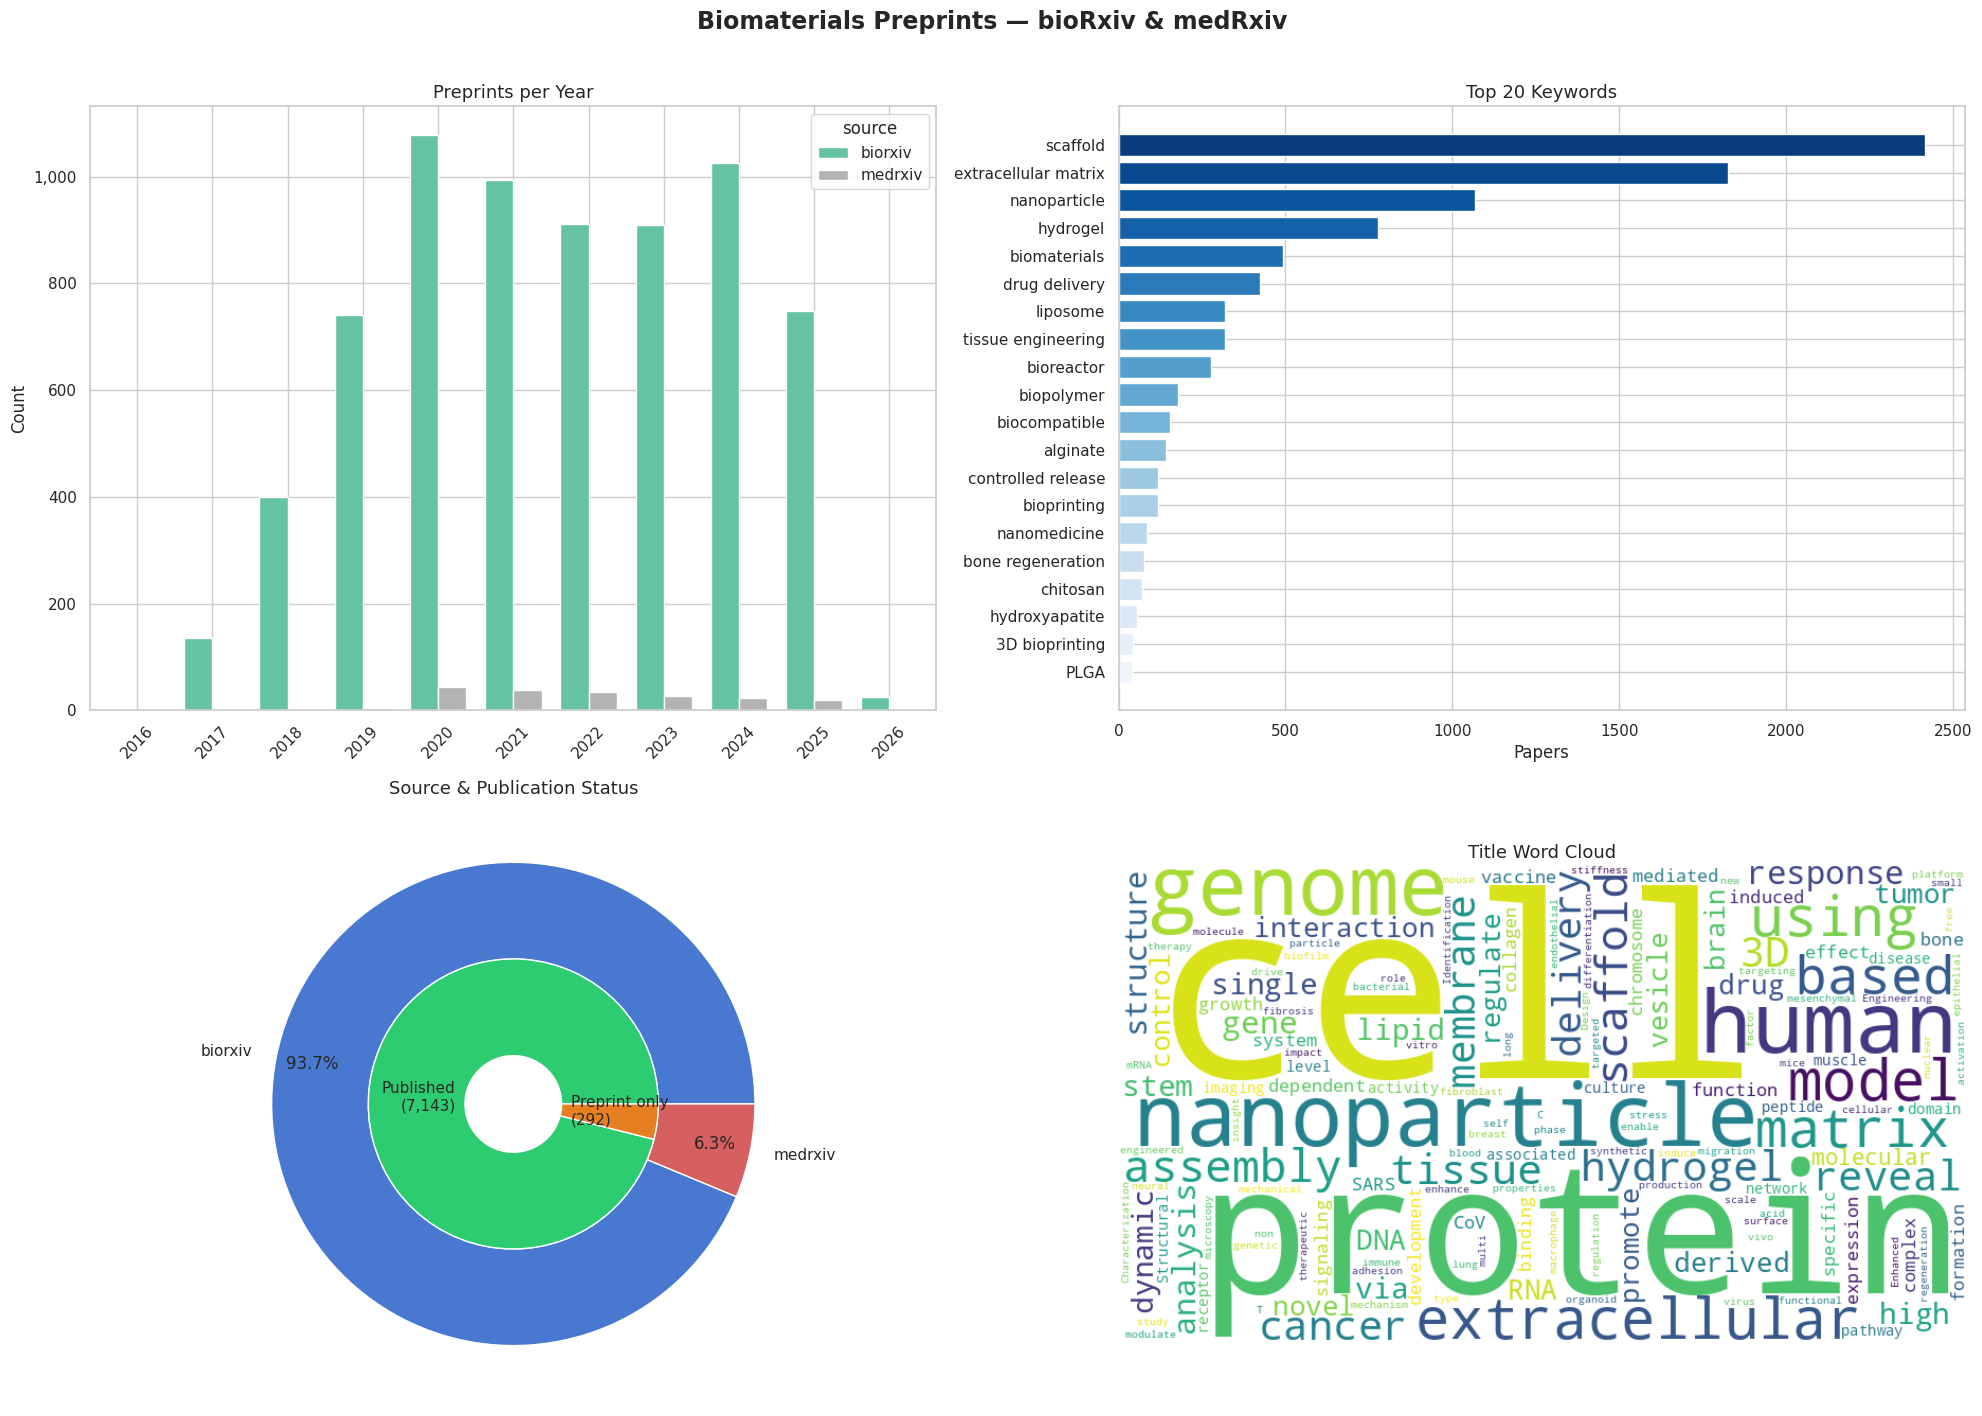

✅ Dashboard saved → biomaterials_dashboard.png


In [13]:
# ============================================================
# Cell 16: Visualisations
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", palette="muted")


def dashboard(conn: sqlite3.Connection):
    fig = plt.figure(figsize=(20, 14))
    fig.suptitle(
        "Biomaterials Preprints — bioRxiv & medRxiv",
        fontsize=17, fontweight="bold", y=1.01
    )

    axes = fig.subplot_mosaic("""
        AABB
        CCDD
    """)

    # ── A: Papers per year ────────────────────────────────
    ax = axes["A"]
    df1 = pd.read_sql_query("""
        SELECT SUBSTR(preprint_date,1,4) yr, source, COUNT(*) cnt
        FROM papers WHERE yr >= '2015' AND yr != ''
        GROUP BY yr, source ORDER BY yr
    """, conn)
    if not df1.empty:
        df1.pivot(index="yr", columns="source", values="cnt")\
           .fillna(0).plot(kind="bar", ax=ax,
                           colormap="Set2", edgecolor="white",
                           width=0.75)
        ax.set_title("Preprints per Year", fontsize=13)
        ax.set_xlabel(""); ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x):,}"
        ))

    # ── B: Top keywords ──────────────────────────────────
    ax = axes["B"]
    df2 = pd.read_sql_query("""
        SELECT keyword, COUNT(*) cnt
        FROM keyword_hits GROUP BY keyword
        ORDER BY cnt DESC LIMIT 20
    """, conn)
    if not df2.empty:
        colors = sns.color_palette("Blues_r", len(df2))
        ax.barh(df2["keyword"], df2["cnt"],
                color=colors, edgecolor="white")
        ax.invert_yaxis()
        ax.set_title("Top 20 Keywords", fontsize=13)
        ax.set_xlabel("Papers")

    # ── C: Source + published pie ──────────────────────
    ax = axes["C"]
    total = conn.execute("SELECT COUNT(*) FROM papers").fetchone()[0]
    pub   = conn.execute("""
        SELECT COUNT(*) FROM papers
        WHERE published_journal IS NOT NULL AND published_journal!=''
    """).fetchone()[0]
    unpub = total - pub

    df_src = pd.read_sql_query(
        "SELECT source, COUNT(*) cnt FROM papers GROUP BY source", conn
    )
    if not df_src.empty and total > 0:
        outer_sizes  = df_src["cnt"].tolist()
        outer_labels = df_src["source"].tolist()
        inner_sizes  = [pub, unpub]
        inner_labels = [f"Published\n({pub:,})",
                        f"Preprint only\n({unpub:,})"]

        ax.pie(outer_sizes, labels=outer_labels, radius=1.0,
               colors=["#4878CF","#D65F5F"],
               wedgeprops=dict(width=0.4, edgecolor="white"),
               autopct="%1.1f%%", pctdistance=0.85)
        ax.pie(inner_sizes, labels=inner_labels, radius=0.6,
               colors=["#2ecc71","#e67e22"],
               wedgeprops=dict(width=0.4, edgecolor="white"),
               labeldistance=0.4)
        ax.set_title("Source & Publication Status", fontsize=13)

    # ── D: Word cloud ──────────────────────────────────
    ax = axes["D"]
    titles = pd.read_sql_query(
        "SELECT preprint_title FROM papers", conn
    )["preprint_title"]
    text = " ".join(titles.dropna().tolist())
    if text.strip():
        wc = WordCloud(
            width=800, height=450,
            background_color="white",
            colormap="viridis",
            max_words=150,
            collocations=False,
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Title Word Cloud", fontsize=13)

    plt.tight_layout()
    out = "biomaterials_dashboard.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Dashboard saved → {out}")


dashboard(conn)

In [14]:
# ============================================================
# Cell 17: Top journals ranking
# ============================================================

def top_journals(conn, limit=20):
    df = pd.read_sql_query(f"""
        SELECT
            published_journal                          AS journal,
            COUNT(*)                                   AS papers,
            ROUND(AVG(cited_by),1)                     AS avg_citations,
            MAX(cited_by)                              AS max_citations,
            MIN(published_date)                        AS first_pub,
            MAX(published_date)                        AS last_pub
        FROM papers
        WHERE published_journal IS NOT NULL
          AND published_journal != ''
        GROUP BY published_journal
        ORDER BY papers DESC
        LIMIT {limit}
    """, conn)
    return df

print("📰 Top journals publishing biomaterials preprints:")
display(top_journals(conn))

📰 Top journals publishing biomaterials preprints:


,journal,papers,avg_citations,max_citations,first_pub,last_pub
0,Nature Communications,332,0.1,6,2018-03-13,2026-03-31
1,eLife,271,0.1,4,2018-04-03,2026-03-03
2,Scientific Reports,203,0.1,8,2018-01-18,2026-03-05
3,Proceedings of the National Academy of Sciences,176,0.1,4,2018-02-20,2026-03-17
4,PLOS ONE,144,0.3,8,2018-01-03,2025-04-10
5,Biomaterials,126,0.1,2,2018-03-02,2026-03-07
6,Science Advances,112,0.0,1,2018-01-12,2026-03-11
7,G3: Genes|Genomes|Genetics,95,0.2,7,2018-03-08,2026-01-03
8,Biophysical Journal,86,0.2,3,2018-01-23,2026-02-28
9,Acta Biomaterialia,80,0.0,2,2018-02-13,2026-02-27


In [15]:
# ============================================================
# Cell 18: Close
# ============================================================

conn.close()
print(f"✅ All done.  Database: {CONFIG['db_path']}")

✅ All done.  Database: biomaterials_papers.db
